In [30]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_selection import RFE
import warnings
warnings.filterwarnings('ignore')

In [31]:
data_location = r"C:\Users\rajeshkumar.t\Desktop\ML\Payment_regression_model.csv"
df = pd.read_csv(data_location)

In [32]:
print(df.columns)

Index(['date', 'pg_id', 'bank_code', 'juspay_sdk', 'phonepe_sdk', 'routing_id',
       'auth_mode', 'payment_instrument', 'emi_type', 'card_network',
       'card_type', 'upi_app_name', 'fraud_recommendation', 'amount_bucket',
       'applied_interest_rate', 'transaction_status', 'live_response_code',
       'query_response_code', 'recon_status', 'marketplace_id', 'txn_count',
       'total_volume'],
      dtype='object')


In [39]:
all_possible_features = [col for col in df.columns if df[col].dtypes != 'object' or df[col].nunique() < 100]
exclude_list = ['transaction_status', 'live_response_code', 'query_response_code', 'date', 'recon_status']
final_features = [col for col in all_possible_features if col not in exclude_list]

X_all = df[final_features].fillna('Unknown')

In [42]:
print(X_all.columns)

Index(['juspay_sdk', 'phonepe_sdk', 'routing_id', 'auth_mode',
       'payment_instrument', 'emi_type', 'card_network', 'card_type',
       'upi_app_name', 'fraud_recommendation', 'amount_bucket',
       'applied_interest_rate', 'marketplace_id', 'txn_count', 'total_volume'],
      dtype='object')


In [61]:
le = LabelEncoder()
for col in X_all.columns:
    if X_all[col].dtype == 'object':
        X_all[col] = le.fit_transform(X_all[col].astype(str))

In [62]:
base_model = RandomForestClassifier(n_estimators = 50 , class_weight = 'balanced', random_state=42)
selector =RFE(base_model, n_features_to_select = 10, step=5)

In [69]:
y= df['transaction_status'].apply(lambda x: 1 if x != 'SUCCESS' else 0 )
selector = selector.fit(X_all, y)

In [73]:
choosen_features = X_all.columns[selector.support_]
print( choosen_features.tolist())

ranking_df = pd.DataFrame({'Feature': X_all.columns, 'Rank': selector.ranking_})
print(ranking_df.sort_values(by='Rank').head(10))

['juspay_sdk', 'routing_id', 'payment_instrument', 'card_network', 'upi_app_name', 'fraud_recommendation', 'amount_bucket', 'marketplace_id', 'txn_count', 'total_volume']
                 Feature  Rank
0             juspay_sdk     1
2             routing_id     1
6           card_network     1
4     payment_instrument     1
12        marketplace_id     1
10         amount_bucket     1
9   fraud_recommendation     1
8           upi_app_name     1
14          total_volume     1
13             txn_count     1


In [74]:
X_final = X_all[choosen_features]
final_model = RandomForestClassifier(n_estimators=100, class_weight= 'balanced', random_state=42)
final_model.fit(X_final, y)

importances = pd.Series(final_model.feature_importances_, index=choosen_features).sort_values(ascending=False)
print("\n--- Final_RCA_Weights--")
print(importances)


--- Final_RCA_Weights--
total_volume            0.451827
routing_id              0.182480
txn_count               0.143136
upi_app_name            0.058592
marketplace_id          0.037500
payment_instrument      0.036779
card_network            0.027650
fraud_recommendation    0.024504
juspay_sdk              0.021003
amount_bucket           0.016530
dtype: float64


In [75]:
import matplotlib.pyplot as plt
import seaborn as sns

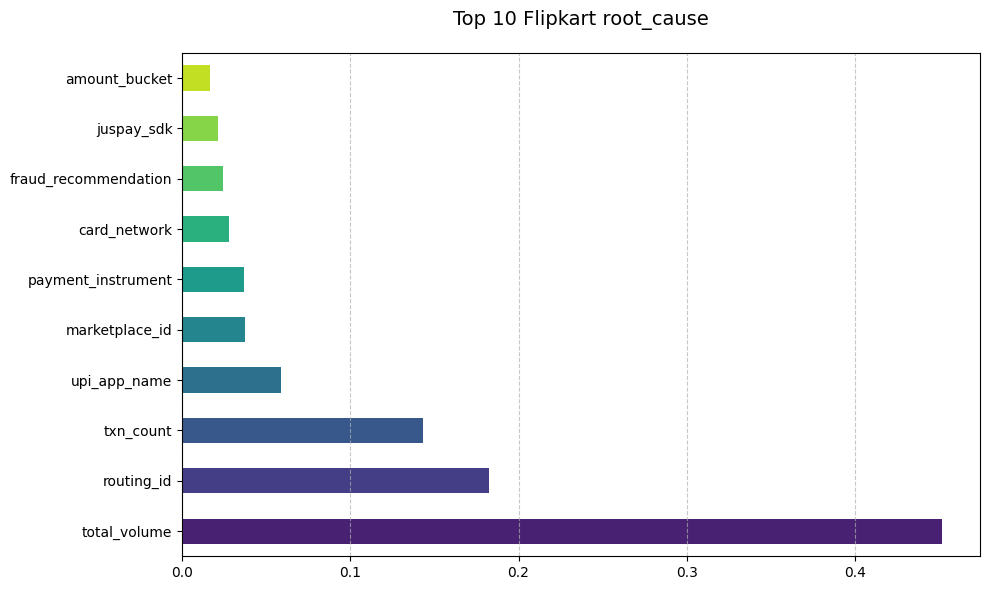

In [76]:
importances= pd.Series(final_model.feature_importances_, index= choosen_features).sort_values(ascending=False)
plt.figure(figsize=(10,6))
plt.title('Top 10 Flipkart root_cause', fontsize =14, pad=20)
plt.xlabel('Feature Importance Score', fontsize=12)

colors = sns.color_palette("viridis", len(importances))
importances.plot(kind='barh', color=colors)

plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()

plt.savefig("Flipkart RCA Drivers")
plt.show()

In [82]:
from sklearn.metrics import confusion_matrix , ConfusionMatrixDisplay
import matplotlib.pyplot as plt

<Figure size 800x600 with 0 Axes>

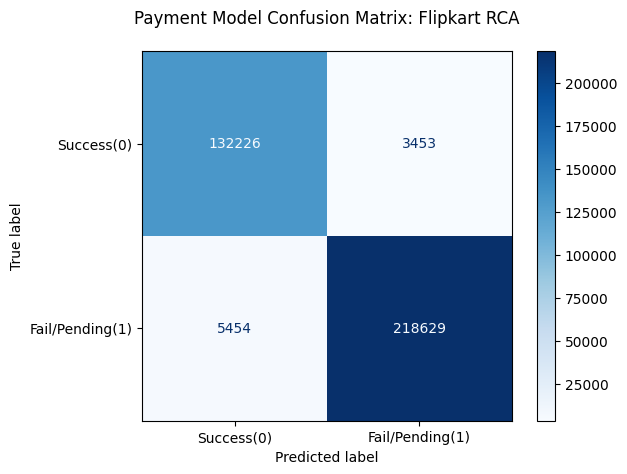

In [84]:
y_pred = final_model.predict(X_final)
cm = confusion_matrix(y, y_pred)
plt.figure(figsize=(8,6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Success(0)', 'Fail/Pending(1)'])
disp.plot(cmap='Blues',values_format ='d')

plt.title('Payment Model Confusion Matrix: Flipkart RCA', pad=20)
plt.show()

In [86]:
tn, fp, fn, tp=cm.ravel()
recall = tp/(tp +fn)
precission = tp/(tp + fp)

print(f"Total Failure Caught (True Positive): {tp}")
print(f"Failure Missed (False Negative): {fn}")
print(f"Recall (Capture Rate): {round(recall*100,2)}%")

Total Failure Caught (True Positive): 218629
Failure Missed (False Negative): 5454
Recall (Capture Rate): 97.57%


In [91]:
df['predicted_risk'] = final_model.predict(X_final)
df['actual_risk'] = (df['transaction_status'] != 'SUCCESS').astype(int)

recoverable_gmv = df[(df['actual_risk'] == 1) & (df['predicted_risk']==1)]['total_volume'].sum()
total_failed_gmv = df[df['actual_risk'] ==1]['total_volume'].sum()
recovery_rate_value = (recoverable_gmv/total_failed_gmv) *100
print(f"Total GMV at risk : {total_failed_gmv:,.2f}")
print(f"GMV Recoverable from model: {recoverable_gmv:,.2f}")
print(f"Financial recall: {round(recovery_rate_value,2)}%")

Total GMV at risk : 15,780,283,416.00
GMV Recoverable from model: 15,654,397,898.00
Financial recall: 99.2%


In [94]:
total_market_baseline = df.groupby('marketplace_id')['total_volume'].sum().reset_index()
total_market_baseline.columns = ['marketplace_id', 'total_gmv_attempted']

leaked_data = df[(df['actual_risk'] == 1) & (df['predicted_risk']==1)]

marketplace_leaks= leaked_data.groupby(['marketplace_id', 'payment_instrument' , 'upi_app_name']).agg(
    leaked_gmv=('total_volume', 'sum'),
    failure_txn_count=('total_volume', 'count')
).reset_index()

final_dashboard = marketplace_leaks.merge(total_market_baseline, on ='marketplace_id', how = 'left')
final_dashboard['leakage_share_pct'] = (final_dashboard['leaked_gmv']/final_dashboard['total_gmv_attempted']) * 100
final_dashboard = final_dashboard.sort_values(by='leaked_gmv', ascending=False)



In [96]:
flipkart_report = final_dashboard[final_dashboard['marketplace_id']== 'FLIPKART'].copy()
flipkart_report = flipkart_report.sort_values(by='leaked_gmv', ascending=False)

fk_total_leak = flipkart_report['leaked_gmv'].sum()
fk_avg_leakage_pct = (fk_total_leak/flipkart_report['total_gmv_attempted'].unique()[0]) * 100

print(f"\n Total Leakage GMV Flipkart: {fk_total_leak:,.2f}")
print(f"\n Over all Flipkart leakage: {round(fk_avg_leakage_pct,2)}%")


 Total Leakage GMV Flipkart: 2,747,912,279.00

 Over all Flipkart leakage: 1.2%


In [101]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt

In [102]:
daily_leakage = df[df['actual_risk']==1].groupby('date')['total_volume'].sum().reset_index()
daily_leakage['day_num'] = np.arange(len(daily_leakage))
X_reg = daily_leakage[['day_num']]
y_reg = daily_leakage['total_volume']

In [103]:
model_forecast = LinearRegression()
model_forecast.fit(X_reg, y_reg)

future_days = np.arange(len(daily_leakage), len(daily_leakage) + 7).reshape(-1, 1)
forecasted_values = model_forecast.predict(future_days)


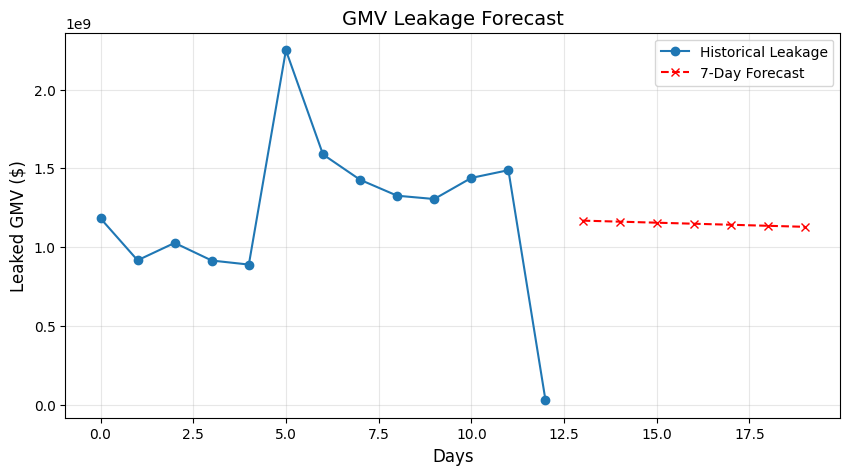

In [112]:
plt.figure(figsize=(10,5))
plt.plot(daily_leakage['day_num'], y_reg, label= 'Historical Leakage', marker='o')
plt.plot(future_days, forecasted_values, label= '7-Day Forecast', linestyle='--', color ='red', marker='x')

plt.title('GMV Leakage Forecast',fontsize=14)
plt.xlabel('Days', fontsize=12)
plt.ylabel('Leaked GMV ($)', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [119]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [123]:
daily_stats = df.groupby('date').agg({
    'total_volume': 'sum',
    'txn_count': 'sum',
    'transaction_status': lambda x:(x != 'SUCCESS').sum()
}).reset_index()

X= daily_stats[['total_volume', 'txn_count']]
y= daily_stats['transaction_status']

X_with_const = sm.add_constant(X)
stats_model = sm.OLS(y, X_with_const).fit()

ml_model = LinearRegression()
ml_model.fit(X, y)
y_pred = ml_model.predict(X)

mse = mean_squared_error(y, y_pred)
r2 = r2_score(y, y_pred)

print("--Statistical Validation---")
print(f"Mean squared Error: {round(mse,2)}")
print("\n--R2 Value---")
print(f"R2 Value:{r2 * 100:.2f}%")
print("\n-- P-Value(significance check")

print(stats_model.pvalues)

print("\n--- Detailed Regresssion Summary--")
print(stats_model.summary().tables[1])


--Statistical Validation---
Mean squared Error: 324497.18

--R2 Value---
R2 Value:98.27%

-- P-Value(significance check
const           1.547613e-03
total_volume    1.753045e-01
txn_count       6.315320e-09
dtype: float64

--- Detailed Regresssion Summary--
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const         2751.3099    638.999      4.306      0.002    1327.531    4175.089
total_volume  2.838e-08   1.95e-08      1.459      0.175    -1.5e-08    7.17e-08
txn_count        0.0010   5.58e-05     17.904      0.000       0.001       0.001


In [129]:
#Cooks Distance to check outlier

import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor 
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt


In [131]:
X = daily_stats[['total_volume', 'txn_count']]
y = daily_stats['transaction_status']
X_with_const = sm.add_constant(X)

--- Check MultiCollinearity Check---
        feature        VIF
0         const  12.583155
1  total_volume   1.597518
2     txn_count   1.597518

--Outlier_dedection--
Identified 2
Outlier dates: ['2026-03-01', '2026-03-13']


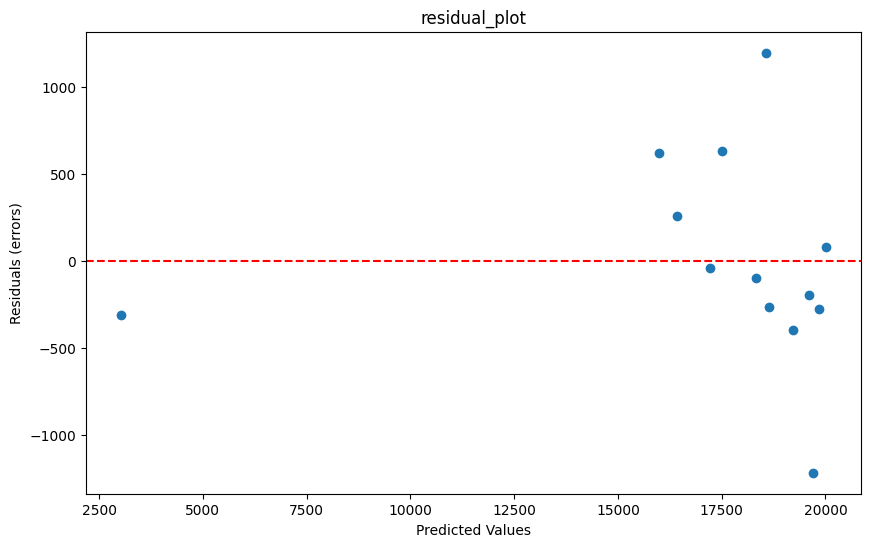

In [147]:
vif_data = pd.DataFrame()
vif_data["feature"] = X_with_const.columns
vif_data["VIF"] = [variance_inflation_factor(X_with_const.values, i) for i in range(len(X_with_const.columns))]

print("--- Check MultiCollinearity Check---")
print(vif_data)

model = sm.OLS(y, X_with_const).fit()
influence = model.get_influence()
cooks_d = influence.cooks_distance[0]

n=len(daily_stats)
threshold = 4/n
outlier_indices = np.where(cooks_d > threshold)[0]

print(f"\n--Outlier_dedection--")
print(f"Identified {len(outlier_indices)}")
print("Outlier dates:", daily_stats.iloc[outlier_indices]['date'].tolist())

plt.figure(figsize=(10,6))
plt.scatter(model.fittedvalues, model.resid)
plt.axhline(0, color='red', linestyle='--')
plt.title('residual_plot')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals (errors)')
plt.show()

    

In [148]:
#The Log-Transformation Method
import numpy as np
import statsmodels.api as sm

daily_stats['log_txn_count'] = np.log1p(daily_stats['txn_count'])
daily_stats['log_failures'] = np.log1p(daily_stats['transaction_status'])

X_log = sm.add_constant(daily_stats['log_txn_count'])
log_model = sm.OLS(daily_stats['log_failures'], X_log).fit()

print("---LOG MODEL SUMMARY---")
print(log_model.summary().tables[1])

                                       

---LOG MODEL SUMMARY---
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const             1.9187      0.150     12.814      0.000       1.589       2.248
log_txn_count     0.4783      0.009     51.905      0.000       0.458       0.499


In [153]:
#WLS Method

weights = daily_stats['txn_count']
wls_model = sm.WLS(y, X_with_const, weights=weights).fit()
print("WLS Summary Report----")
print(wls_model.summary().tables[1])

WLS Summary Report----
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const         6298.3805   1937.787      3.250      0.009    1980.723    1.06e+04
total_volume   3.52e-08   1.68e-08      2.096      0.062   -2.21e-09    7.26e-08
txn_count        0.0008      0.000      5.565      0.000       0.000       0.001
